In [9]:
import model as m
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
import numpy as np

### Parameter Values

Controllable Parameters

name | units | description
--- | --- | --- 
$K$ | `f` | carrying capacity of frog saunas, a function of $u_1$
$\xi$ | `1 / t` | rate of transfer into antifungal treatment, a function of $u_2$

Constant Parameters

name | units | description
--- | --- | --- 
$\alpha$ | `1 / f / t` | infection rate from living hosts
$\beta$ | `1 / t` | death rate from disease
$\gamma$ | `1 / f / t` | rate that frogs leave sauna
$\zeta$ | `1 / t` | rate of transfer to heat treatment
$\eta$ | `1` (unitless) | success rate of antifungal bath treatment

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.002e-01 ...  1.499e+03  1.500e+03]
        y: [[ 4.750e+02  4.749e+02 ...  1.628e+01  1.627e+01]
            [ 2.500e+01  2.507e+01 ...  1.145e+01  1.144e+01]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  2.504e-02 ...  4.723e+02  4.723e+02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 92
     njev: 0
      nlu: 0

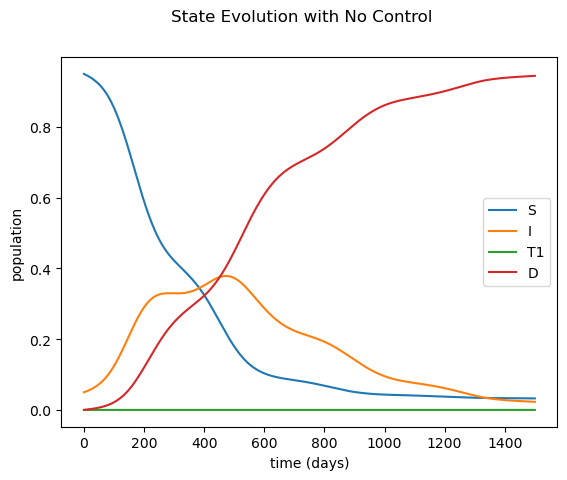

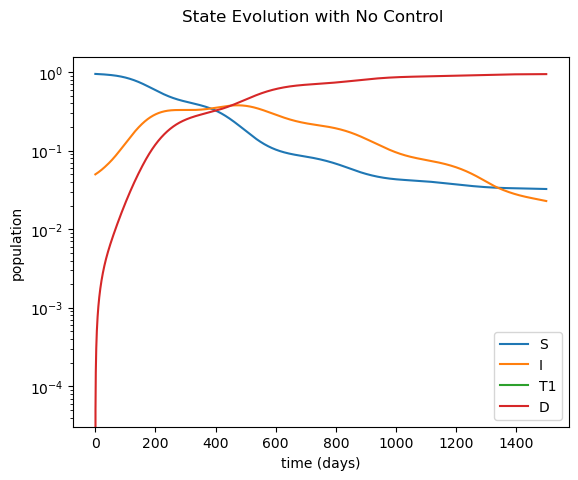

In [ ]:
# No Controls, autonomous evolution, seasonal

tsteps = 3000

# params
y_init = np.array([475, 25, 0, 0]) # 500 total 25 initially infected
gamma, zeta = 0.1, 0.15 # central time average parameter estimates
K, eta, xi = lambda u1: 365 * u1 / 2, lambda u2: 1, lambda u2, I: u2 / (I + 50) / 100 # control functions
control1 = 0, 0 # we have no frog hotels
control2 = K, eta, xi # other parameters

# season starts in summer
theta = lambda t: 2 * np.pi * t / 365
alpha = lambda theta: 0.000025 * (1 + 0.5 * np.cos(theta + 1.25 * np.pi)) # seasonal alpha
beta = lambda theta: ((0.002 + 0.005) + (0.005 - 0.002) * np.cos(theta + np.pi))/2 # seasonal beta

# solve for tf days
t0, tf = 0, 1500
sol = solve_ivp(
    m.model_equation,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=[theta, control1, control2, alpha, gamma, zeta, beta]
    )

display(sol)

# graph each compartment
plt.plot(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.plot(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.plot(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.plot(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with No Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

plt.show()

# log log

plt.semilogy(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.semilogy(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.semilogy(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with No Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.002e-01 ...  1.499e+03  1.500e+03]
        y: [[ 4.750e+02  4.602e+02 ...  2.600e+02  2.600e+02]
            [ 2.500e+01  2.426e+01 ...  3.679e+00  3.674e+00]
            [ 0.000e+00  1.555e+01 ...  1.745e+01  1.743e+01]
            [ 0.000e+00  2.452e-02 ...  2.189e+02  2.189e+02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 9008
     njev: 0
      nlu: 0

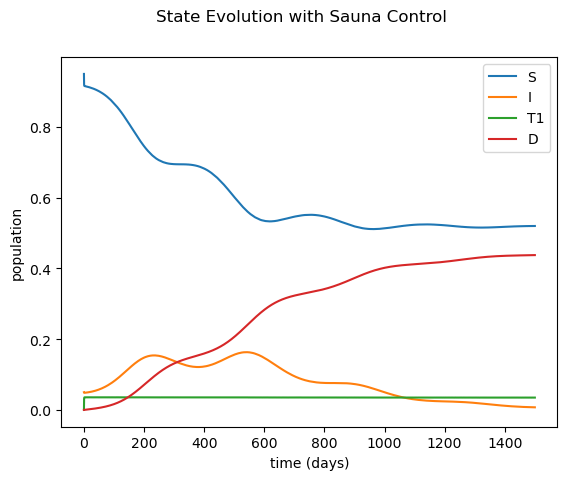

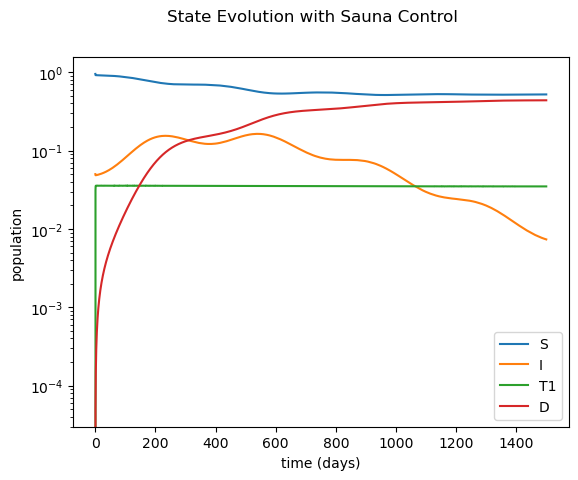

In [28]:
# $1 / day in Frog Sauna, autonomous evolution

tsteps = 3000

# params
y_init = np.array([475, 25, 0, 0]) # 500 total 25 initially infected
gamma, zeta = 0.1, 0.15 # central time average parameter estimates
K, eta, xi = lambda u1: 365 * u1 / 2, lambda u2: 1, lambda u2, I: u2 / (I + 50) / 100 # control functions
control1 = 0.10, 0 # we have some frog hotels
control2 = K, eta, xi # other parameters

# season starts in summer
theta = lambda t: 2 * np.pi * t / 365
alpha = lambda theta: 0.000025 * (1 + 0.5 * np.cos(theta + 1.25 * np.pi)) # seasonal alpha
beta = lambda theta: ((0.002 + 0.005) + (0.005 - 0.002) * np.cos(theta + np.pi))/2 # seasonal beta

# solve for tf days
t0, tf = 0, 1500
sol = solve_ivp(
    m.model_equation,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=[theta, control1, control2, alpha, gamma, zeta, beta]
    )

display(sol)

# graph each compartment
plt.plot(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.plot(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.plot(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.plot(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with Sauna Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

plt.show()

# log log

plt.semilogy(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.semilogy(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.semilogy(sol.t, sol.y[2] / np.sum(y_init), label="T1")
# plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="T2")
plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with Sauna Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.003e-01 ...  9.995e+02  1.000e+03]
        y: [[ 4.750e+02  4.749e+02 ...  4.943e+01  4.944e+01]
            [ 2.500e+01  2.505e+01 ...  4.645e+01  4.636e+01]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  2.504e-02 ...  4.041e+02  4.042e+02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 86
     njev: 0
      nlu: 0

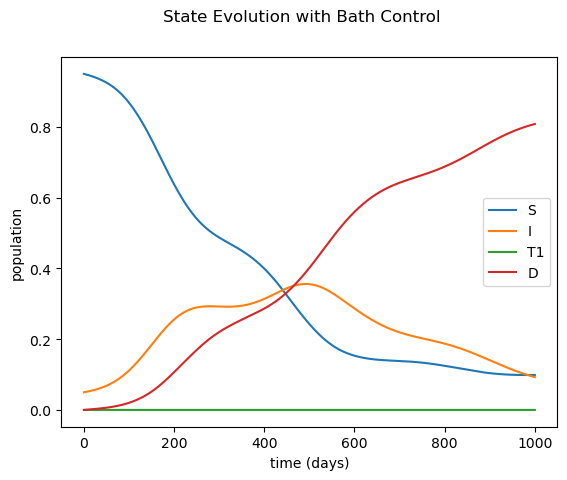

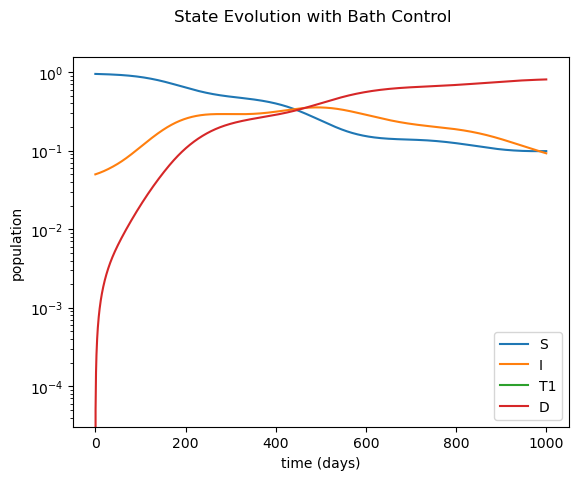

In [31]:
# $1000 / day in Frog treatment, autonomous evolution

tsteps = 2000

# params
y_init = np.array([475, 25, 0, 0]) # 500 total 25 initially infected
gamma, zeta = 0.1, 0.15 # central time average parameter estimates
K, eta, xi = lambda u1: 365 * u1 / 2, lambda u2: 1, lambda u2, I: u2 / (I + 50) / 100 # control functions
control1 = 0, 10 # we have some frog bathers
control2 = K, eta, xi # other parameters

# season starts in summer
theta = lambda t: 2 * np.pi * t / 365
alpha = lambda theta: 0.000025 * (1 + 0.5 * np.cos(theta + 1.25 * np.pi)) # seasonal alpha
beta = lambda theta: ((0.002 + 0.005) + (0.005 - 0.002) * np.cos(theta + np.pi))/2 # seasonal beta

# solve for tf days
t0, tf = 0, 1000
sol = solve_ivp(
    m.model_equation,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=[theta, control1, control2, alpha, gamma, zeta, beta]
    )

display(sol)

# graph each compartment
plt.plot(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.plot(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.plot(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.plot(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with Bath Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

plt.show()

# log log

plt.semilogy(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.semilogy(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.semilogy(sol.t, sol.y[2] / np.sum(y_init), label="T1")
# plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="T2")
plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with Bath Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.003e-01 ...  9.995e+02  1.000e+03]
        y: [[ 4.750e+02  4.602e+02 ...  2.932e+02  2.932e+02]
            [ 2.500e+01  2.425e+01 ...  2.298e+01  2.291e+01]
            [ 0.000e+00  1.555e+01 ...  1.755e+01  1.757e+01]
            [ 0.000e+00  2.451e-02 ...  1.663e+02  1.663e+02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 6950
     njev: 0
      nlu: 0

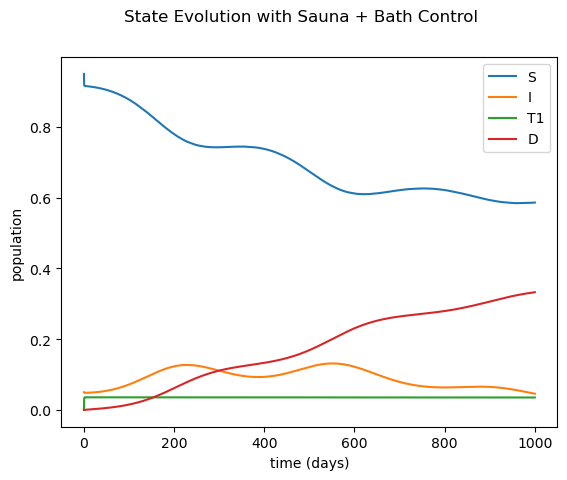

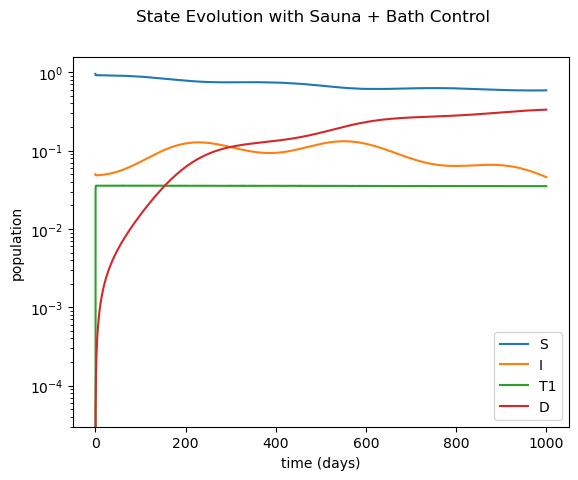

In [34]:
# $1000 / day in Frog treatment, $10 in sauna, autonomous evolution

tsteps = 2000

# params
y_init = np.array([475, 25, 0, 0]) # 500 total 25 initially infected
gamma, zeta = 0.1, 0.15 # central time average parameter estimates
K, eta, xi = lambda u1: 365 * u1 / 2, lambda u2: 1, lambda u2, I: u2 / (I + 50) / 100 # control functions
control1 = .1, 10 # we have some frog bathers
control2 = K, eta, xi # other parameters

# season starts in summer
theta = lambda t: 2 * np.pi * t / 365
alpha = lambda theta: 0.000025 * (1 + 0.5 * np.cos(theta + 1.25 * np.pi)) # seasonal alpha
beta = lambda theta: ((0.002 + 0.005) + (0.005 - 0.002) * np.cos(theta + np.pi))/2 # seasonal beta

# solve for tf days
t0, tf = 0, 1000
sol = solve_ivp(
    m.model_equation,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=[theta, control1, control2, alpha, gamma, zeta, beta]
    )

display(sol)

# graph each compartment
plt.plot(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.plot(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.plot(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.plot(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with Sauna + Bath Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

plt.show()

# log log

plt.semilogy(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.semilogy(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.semilogy(sol.t, sol.y[2] / np.sum(y_init), label="T1")
# plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="T2")
plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with Sauna + Bath Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()